# Assignment 5

## Section A — Short Theory Questions

### 1. What is Machine Learning, and how does supervised learning differ from unsupervised learning?

**Machine Learning** is a field of AI where systems learn patterns from data and improve their performance on a task without being explicitly programmed with fixed rules.

**Supervised learning** uses labeled data (input paired with known output) to train a model that predicts outputs for new inputs — e.g., predicting house prices from features. **Unsupervised learning** uses unlabeled data and tries to find hidden patterns or groupings on its own — e.g., clustering customers based on behavior, with no predefined "correct answer."

---

### 2. What are the main steps of a classical machine learning pipeline?

1. **Data Collection** — gathering raw data relevant to the problem.
2. **Data Preprocessing** — cleaning data, handling missing values, encoding categorical variables, feature scaling.
3. **Splitting Data** — dividing into training and testing sets.
4. **Model Selection** — choosing an appropriate algorithm.
5. **Training** — fitting the model on training data.
6. **Evaluation** — testing model performance using metrics (accuracy, MSE, etc.) on unseen data.
7. **Tuning/Optimization** — adjusting hyperparameters to improve performance.
8. **Deployment** — using the trained model to make real predictions.

---

### 3. What is a cost function, and what role does gradient descent play in minimizing it?

A **cost function** measures how far off a model's predictions are from the actual values — a lower cost means a better-fitting model. Example: Mean Squared Error in linear regression.

**Gradient descent** is an optimization algorithm that iteratively adjusts the model's parameters (weights) in the direction that reduces the cost function the most, gradually moving toward the minimum cost (best-fit parameters), using the gradient (slope) of the cost function at each step.

---

### 4. What is the difference between linear regression and logistic regression? Why can't logistic regression use the same cost function as linear regression?

**Linear regression** predicts continuous numeric values (e.g., price) using a straight-line relationship between inputs and output.

**Logistic regression** predicts categorical outcomes (e.g., Yes/No) by using the sigmoid function to output a probability between 0 and 1.

Logistic regression can't use the same cost function (Mean Squared Error) as linear regression because, when combined with the non-linear sigmoid function, MSE becomes a **non-convex** function with many local minima — making gradient descent unreliable. Instead, logistic regression uses **log loss (cross-entropy)**, which remains convex and guarantees gradient descent can find the global minimum.

---

### 5. What is overfitting, and how does polynomial regression relate to this risk?

**Overfitting** happens when a model learns the training data too well — including its noise and random fluctuations — resulting in excellent performance on training data but poor generalization to new, unseen data.

**Polynomial regression** increases model complexity by adding higher-degree terms (x², x³, etc.) to fit curved relationships. While this can capture non-linear patterns better than a straight line, using too high a degree makes the curve fit the training points too precisely, increasing the risk of overfitting and reducing the model's ability to generalize.

## Section B - Task 1: Univariate Linear Regression from Scratch (Gradient Descent)

Slope (m): 64.4087325952104
Intercept (c): 149.99999974755485


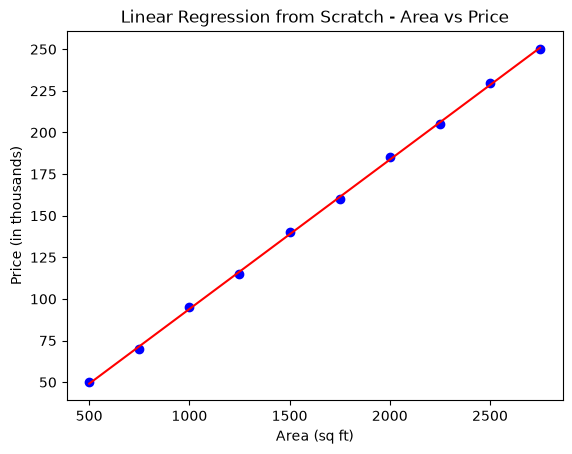

In [1]:
import numpy as np
import matplotlib.pyplot as plt

area = np.array([500, 750, 1000, 1250, 1500, 1750, 2000, 2250, 2500, 2750])
price = np.array([50, 70, 95, 115, 140, 160, 185, 205, 230, 250])

area_norm = (area - area.mean()) / area.std()

m, c = 0, 0
learning_rate = 0.01
epochs = 1000
n = len(area_norm)

for i in range(epochs):
    y_pred = m * area_norm + c
    dm = (-2/n) * np.sum(area_norm * (price - y_pred))
    dc = (-2/n) * np.sum(price - y_pred)
    m -= learning_rate * dm
    c -= learning_rate * dc

print("Slope (m):", m)
print("Intercept (c):", c)

plt.scatter(area, price, color='blue')
plt.plot(area, m*area_norm + c, color='red')
plt.title("Linear Regression from Scratch - Area vs Price")
plt.xlabel("Area (sq ft)")
plt.ylabel("Price (in thousands)")
plt.show()

## Section B - Task 2: Linear Regression using sklearn - Comparison

In [10]:
%pip install scikit-learn


Note: you may need to restart the kernel to use updated packages.


In [12]:
from sklearn.linear_model import LinearRegression

X = area.reshape(-1, 1)
model = LinearRegression()
model.fit(X, price)

print("Sklearn Coefficient:", model.coef_[0])
print("Sklearn Intercept:", model.intercept_)
print("From-scratch Slope (normalized):", m)
print("From-scratch Intercept:", c)

Sklearn Coefficient: 0.08969696969696969
Sklearn Intercept: 4.242424242424249
From-scratch Slope (normalized): 64.4087325952104
From-scratch Intercept: 149.99999974755485


## Section B - Task 3: Multivariate Linear Regression

In [13]:
import pandas as pd

data = pd.DataFrame({
    "Area": [500, 750, 1000, 1250, 1500, 1750, 2000, 2250, 2500, 2750],
    "Bedrooms": [1, 2, 2, 3, 3, 3, 4, 4, 4, 5],
    "Age": [10, 8, 15, 5, 12, 3, 7, 20, 2, 6],
    "Price": [50, 70, 95, 115, 140, 160, 185, 205, 230, 250]
})

X_multi = data[["Area", "Bedrooms", "Age"]]
y_multi = data["Price"]

multi_model = LinearRegression()
multi_model.fit(X_multi, y_multi)

print("Coefficients:", multi_model.coef_)
print("Intercept:", multi_model.intercept_)

Coefficients: [ 0.09209495 -1.56125574  0.00995406]
Intercept: 5.098009188361345


## Section B - Task 4: Polynomial Regression - Experience vs Salary

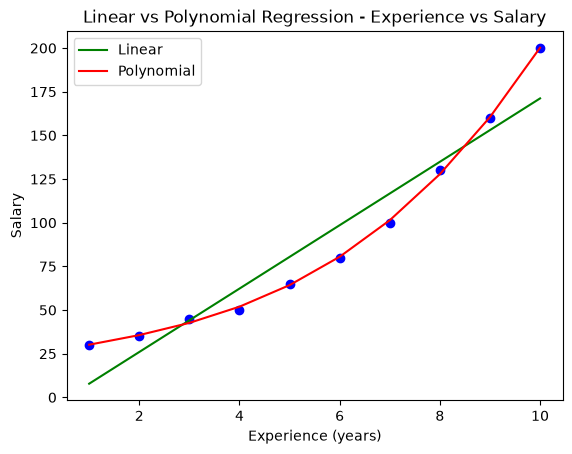

In [14]:
from sklearn.preprocessing import PolynomialFeatures

experience = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10]).reshape(-1, 1)
salary = np.array([30, 35, 45, 50, 65, 80, 100, 130, 160, 200])

lin_model = LinearRegression()
lin_model.fit(experience, salary)

poly = PolynomialFeatures(degree=3)
experience_poly = poly.fit_transform(experience)
poly_model = LinearRegression()
poly_model.fit(experience_poly, salary)

plt.scatter(experience, salary, color='blue')
plt.plot(experience, lin_model.predict(experience), color='green', label='Linear')
plt.plot(experience, poly_model.predict(experience_poly), color='red', label='Polynomial')
plt.title("Linear vs Polynomial Regression - Experience vs Salary")
plt.xlabel("Experience (years)")
plt.ylabel("Salary")
plt.legend()
plt.show()

## Section B - Task 5: Logistic Regression - Binary Classification (Admission)

In [15]:
from sklearn.linear_model import LogisticRegression

admission_data = pd.DataFrame({
    "TestScore": [65, 70, 55, 80, 90, 40, 75, 85, 60, 95],
    "GPA": [2.5, 3.0, 2.0, 3.5, 3.8, 1.8, 3.2, 3.6, 2.4, 3.9],
    "Admitted": [0, 1, 0, 1, 1, 0, 1, 1, 0, 1]
})

X_adm = admission_data[["TestScore", "GPA"]]
y_adm = admission_data["Admitted"]

log_model = LogisticRegression()
log_model.fit(X_adm, y_adm)

predictions = log_model.predict(X_adm)
print("Predictions:", predictions)
print("Actual:", y_adm.values)

Predictions: [0 1 0 1 1 0 1 1 0 1]
Actual: [0 1 0 1 1 0 1 1 0 1]


## Section B - Task 6: Logistic Regression - Multiclass Classification (Grades)

In [18]:
grade_data = pd.DataFrame({
    "Marks": [95, 88, 76, 65, 55, 45, 92, 70, 60, 40],
    "Grade": ["A", "A", "B", "B", "C", "C", "A", "B", "C", "C"]
})

X_grade = grade_data[["Marks"]]
y_grade = grade_data["Grade"]

multi_log_model = LogisticRegression(max_iter=1000)
multi_log_model.fit(X_grade, y_grade)

grade_predictions = multi_log_model.predict(X_grade)
print("Predictions:", grade_predictions)
print("Actual:", y_grade.values)

Predictions: ['A' 'A' 'B' 'B' 'C' 'C' 'A' 'B' 'C' 'C']
Actual: <StringArray>
['A', 'A', 'B', 'B', 'C', 'C', 'A', 'B', 'C', 'C']
Length: 10, dtype: str


## Section B - Task 7: Model Evaluation

In [19]:
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix

price_pred = model.predict(X)
mse = mean_squared_error(price, price_pred)
r2 = r2_score(price, price_pred)
print("Linear Regression - MSE:", mse)
print("Linear Regression - R2 Score:", r2)

adm_accuracy = accuracy_score(y_adm, predictions)
adm_cm = confusion_matrix(y_adm, predictions)
print("Logistic Regression - Accuracy:", adm_accuracy)
print("Confusion Matrix:\n", adm_cm)

Linear Regression - MSE: 1.515151515151524
Linear Regression - R2 Score: 0.9996349032493611
Logistic Regression - Accuracy: 1.0
Confusion Matrix:
 [[4 0]
 [0 6]]
